In [1]:
# Import các thư viện cần thiết để phân tích
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ẩn các thông báo lỗi từ python
import warnings
warnings.filterwarnings('ignore')

In [2]:
name_lst = ['Nguyễn Hữu Hùng', 'Dương Phan Huy Đức']
task_lst = ['Làm sạc dữ liệu, Thực hiện các bước phân tích thống kê doanh thu, Đưa ra giải pháp kinh tế cải thiện doanh thu', 'Trực quan hóa các biểu đồ, Thực hiện các bước phân tích thống kê lợi nhuận, Đưa ra giải pháp kinh tế cải thiện lợi nhuận']
ratio_lst = ['100%', '100%']
rate_df = pd.DataFrame({'Họ và tên' : name_lst, 'Công việc' : task_lst, 'Tỉ lệ hoàn thành' : ratio_lst})
pd.set_option('display.max_colwidth', None)

In [3]:
rate_df.head()

,Họ và tên,Công việc,Tỉ lệ hoàn thành
0,Nguyễn Hữu Hùng,"Làm sạc dữ liệu, Thực hiện các bước phân tích thống kê doanh thu, Đưa ra giải pháp kinh tế cải thiện doanh thu",100%
1,Dương Phan Huy Đức,"Trực quan hóa các biểu đồ, Thực hiện các bước phân tích thống kê lợi nhuận, Đưa ra giải pháp kinh tế cải thiện lợi nhuận",100%


In [4]:
# Load tập dữ liệu
df = pd.read_excel('Global Superstore.xls')
# In ra 5 dòng đầu tiên của tập dữ liệu
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wireless Headset System,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


# Câu 1

In [5]:
# Lọc các dòng thuộc quốc gia Indonesia
indo_df = df[df['Country'] == 'Indonesia']

# Tính tỷ lệ của tập dữ liệu
data_ratio = (indo_df.shape[0] / df.shape[0]) * 100

print('Tổng số bản ghi:', df.shape[0],
      '\nSố bản ghi:', indo_df.shape[0],
      '\nTỷ lệ dữ liệu:', round(data_ratio, 2), '%')

Tổng số bản ghi: 51290 
Số bản ghi: 1390 
Tỷ lệ dữ liệu: 2.71 %


In [6]:
# Xử lý dữ liệu trùng lập, thiếu và chuẩn hóa loại dữ liệu của các cột cần thiết
def data_preprocessing(df):
    # Đổi kiểu dữ liệu cho cột Date
    df['Order Date'] = pd.to_datetime(df['Order Date'])
    df['Ship Date'] = pd.to_datetime(df['Ship Date'])
    remove_duplicated = df.drop_duplicates() # Xóa giá trị lập lại
    duplicated_check = remove_duplicated.duplicated().sum() # Kiểm tra lại giá trị lập
    remove_na = df.drop(columns = 'Postal Code') # Xóa cột Postal code
    check_nan = remove_na.isnull().sum() # Kiểm tra các giá trị còn thiếu

    for col in remove_na.columns.to_list():
        if remove_na[col].dtypes == 'float64': # đổi kiểu dữ liệu thành số thập phân
            remove_na[col] = round(remove_na[col], 2)
    print('Số bản ghi trùng lập sau khi preprocessing:', duplicated_check)
    print('Giá trị thiếu trong từng cột sau khi preprocessing:\n', check_nan)

    return remove_na

In [7]:
cleaned_df = data_preprocessing(indo_df)

Số bản ghi trùng lập sau khi preprocessing: 0
Giá trị thiếu trong từng cột sau khi preprocessing:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
dtype: int64


In [8]:
# Tạo cột thời gian đơn hàng được xử lý
def new_feature(df):
    df['Order Processed Time'] = (df['Ship Date'] - df['Order Date']).dt.days
    return df

indo_df = new_feature(cleaned_df)

In [9]:
indo_df.to_csv('indonesia.csv', index = False)

# Câu 2

In [10]:
# Phân tích tổng quan Indonesia
def analyze_market_overview(df):
    order = len(df['Order ID']) # tổng số đơn đặt hàng
    customer = len(df['Customer ID'].unique()) # số lượng khách
    product = len(df['Product ID'].unique()) # số lượng sản phẩm
    sales = round(df['Sales'].sum(), 2) # tổng số doanh thu
    profit = round(df['Profit'].sum(), 2) # tổng sổ lợi nhuận
    process_order = round(np.mean(df['Order Processed Time']), 2) # thời gian xử lý đơn hàng trung bình
    name_list = ['Tổng số đơn hàng', 'Tổng số doanh số', 'Tổng số lợi nhuận', 'Số lượng khách hàng', 'Số lượng sản phẩm', 'Thời gian xử lí đơn hàng trung bình']
    value_list = [order, sales, profit, customer, product, process_order]
    new_df = pd.DataFrame({'Hệ số' : name_list, 'Giá trị' : value_list})
    return new_df

overview_indo = analyze_market_overview(indo_df)
print('Tổng quang thị trường Indonesia')
print(overview_indo)

Tổng quang thị trường Indonesia
                                 Hệ số    Giá trị
0                     Tổng số đơn hàng    1390.00
1                     Tổng số doanh số  404887.58
2                    Tổng số lợi nhuận   15608.72
3                  Số lượng khách hàng     469.00
4                    Số lượng sản phẩm    1003.00
5  Thời gian xử lí đơn hàng trung bình       3.98


In [11]:
# Tạo biến phần trăm lợi nhuận
indo_df['Profit Percentage'] = (indo_df['Profit'] / indo_df['Sales']) * 100

In [12]:
# Phân tích theo category
def analyze_category(df):
    sum_ = df.groupby('Category')[['Sales', 'Profit', 'Quantity']].sum() # tổng doanh thu, lợi nhuận và số lượng
    avg = round(df.groupby('Category')['Profit Percentage'].mean(), 2) # tính lợi nhuận trung bình
    concat_df = pd.concat([sum_, avg], axis = 1)
    return concat_df

print('Phân tích theo category:')
category_analysis = analyze_category(indo_df)
print(category_analysis)

Phân tích theo category:
                     Sales    Profit  Quantity  Profit Percentage
Category                                                         
Furniture        140037.92  -1377.12      1031              -0.68
Office Supplies  118777.86   1694.47      3192             -18.22
Technology       146071.80  15291.37      1014              -1.04


In [13]:
# Phân tích segment
def analyze_segment(df):
    sum_ = df.groupby('Segment')[['Sales', 'Profit']].sum() # tính tổng doanh thu và lợi nhuận
    id_ = df.groupby('Segment')['Customer ID'].nunique() # đếm đơn hàng
    concat_df = pd.concat([sum_, id_], axis = 1)
    return concat_df

print('Phân tích theo segment:')
segment_analysis = analyze_segment(indo_df)
print(segment_analysis)

Phân tích theo segment:
                 Sales   Profit  Customer ID
Segment                                     
Consumer     211239.63  7445.64          249
Corporate    128904.76  5472.35          144
Home Office   64743.19  2690.73           76


In [14]:
# Phân tích tháng
def analyze_month(df):
    new_data = df.copy()
    new_data['Order Date'] = new_data['Order Date'].dt.month # lọc tháng
    sum_ = new_data.groupby('Order Date')[['Sales', 'Quantity']].sum() # tổng doanh thu và số lượng
    id_ = new_data.groupby('Order Date')['Order ID'].nunique() # đếm đơn hàng
    concatenate_df = pd.concat([sum_, id_], axis = 1)
    return concatenate_df

print('Thống kê theo tháng:')
month_analysis = analyze_month(indo_df)
print(month_analysis)

Thống kê theo tháng:
               Sales  Quantity  Order ID
Order Date                              
1           22638.58       248        32
2           18115.08       257        31
3           16250.30       255        37
4           22909.61       296        33
5           25692.13       409        61
6           60315.00       683        90
7           37120.78       383        41
8           42655.98       532        75
9           20436.55       361        61
10          49686.29       559        80
11          39141.83       631        72
12          49925.45       623        85


# Câu 3

In [21]:
# Trực quan hóa đồ thị đường
def line_plot(df, column, label):

    # Lọc ra các tháng
    month = df[['Order Date', column]]
    month['Order Date'] = month['Order Date'].dt.to_period('M')  
    month = month.groupby('Order Date')[column].sum().reset_index()
    month['Order Date'] = month['Order Date'].astype(str)
    quart = df[['Order Date', column]]
    quart['Order Date'] = quart['Order Date'].dt.to_period('Q')  
    quart = quart.groupby('Order Date')[column].sum().reset_index()
    quart['Order Date'] = quart['Order Date'].astype(str)
    quart['Order Date'] = pd.to_datetime(quart['Order Date'].astype(str).apply(lambda x: pd.Period(x, freq='Q-DEC').end_time))
    quart['Order Date'] = quart['Order Date'].dt.to_period('M')
    quart['Order Date'] = quart['Order Date'].astype(str)

    # Tạo plot
    plt.figure(figsize=(20,5))
    # Vẽ đường tháng và quý
    sns.lineplot(data = month, x = 'Order Date', y = column, label = label + ' hàng tháng', markers = 's')
    sns.lineplot(data = quart, x = 'Order Date', y = column, label = label + ' hàng quý', marker = "s")
    # Trang trí plot
    plt.xlabel('Thời gian')
    plt.ylabel(label)
    plt.title('Xu hướng ' + label + ' theo thời gian')
    plt.xticks(rotation = 45)
    plt.legend(title = 'Gộp dữ liệu')
    plt.tight_layout()
    # Show plot
    plt.show()

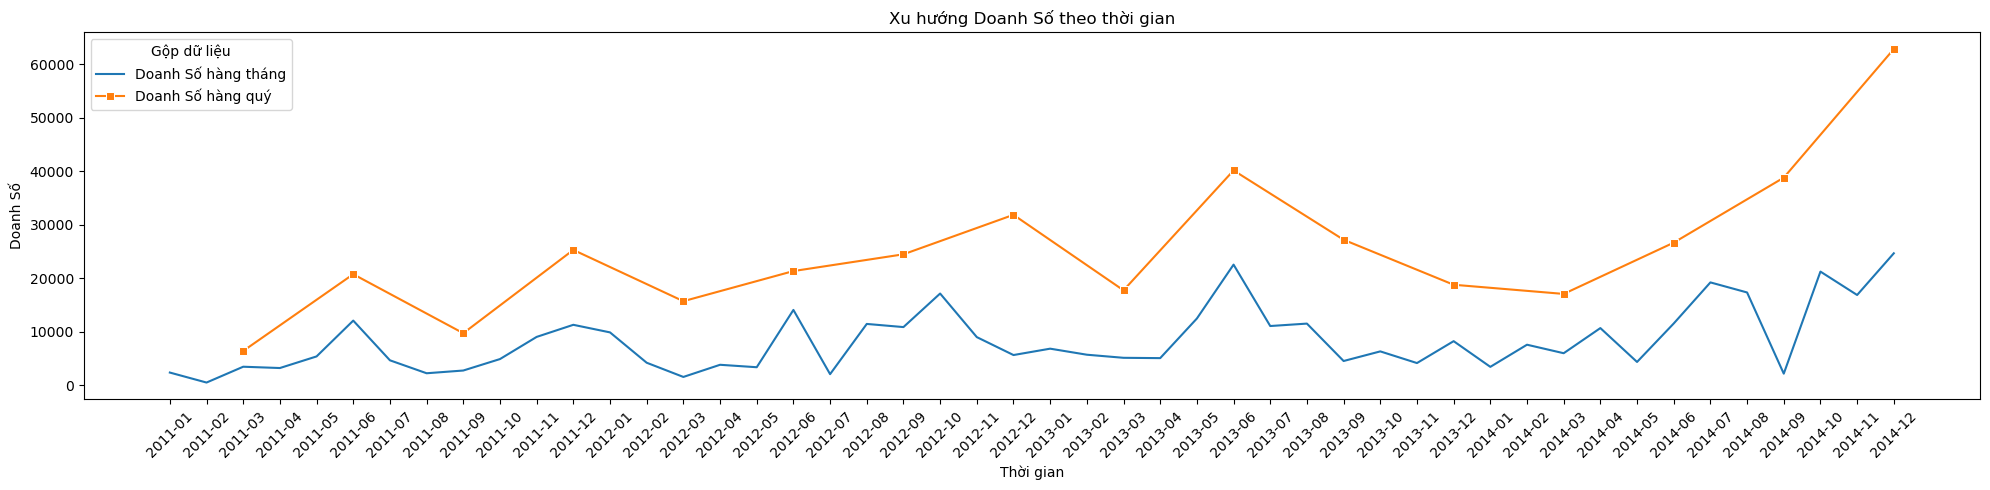

In [22]:
# Vẽ biểu đồ doanh thu 
line_plot(indo_df, 'Sales', 'Doanh Số')

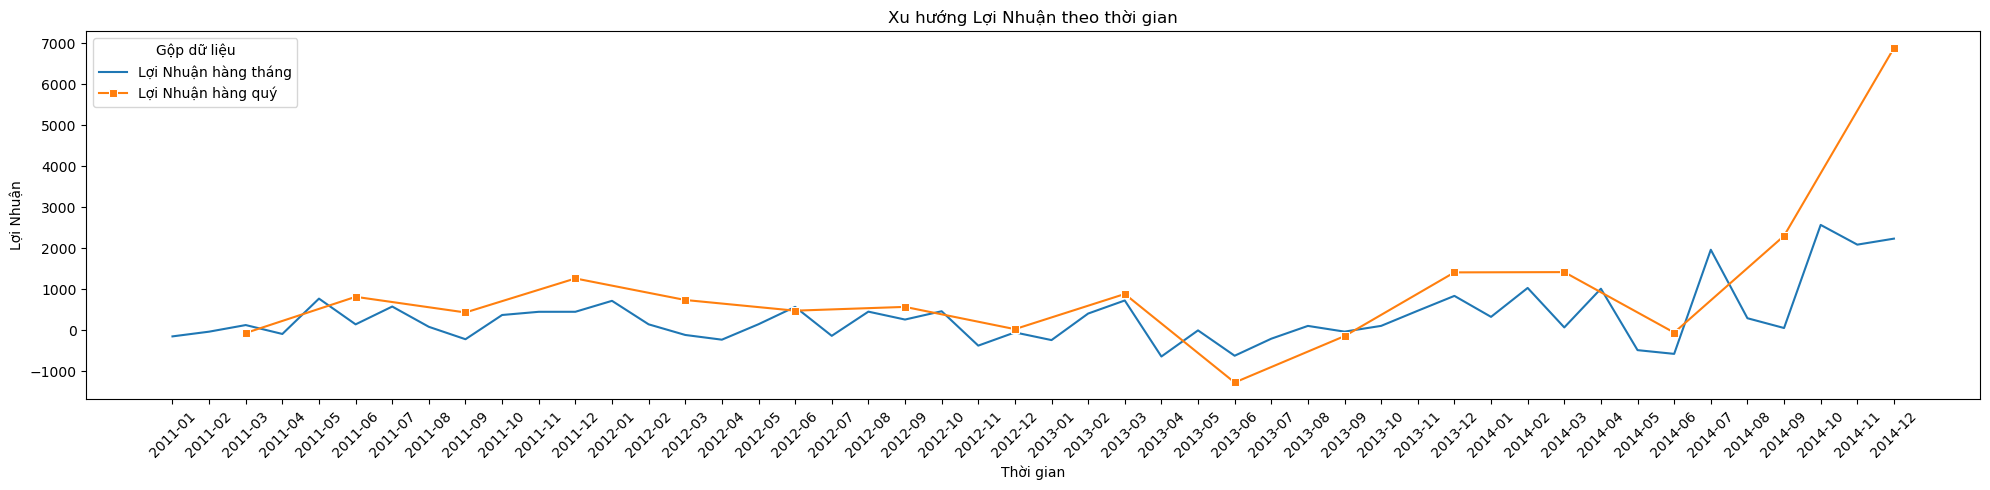

In [23]:
# Vẽ biểu đồ lợi nhuận
line_plot(indo_df, 'Profit', 'Lợi Nhuận')

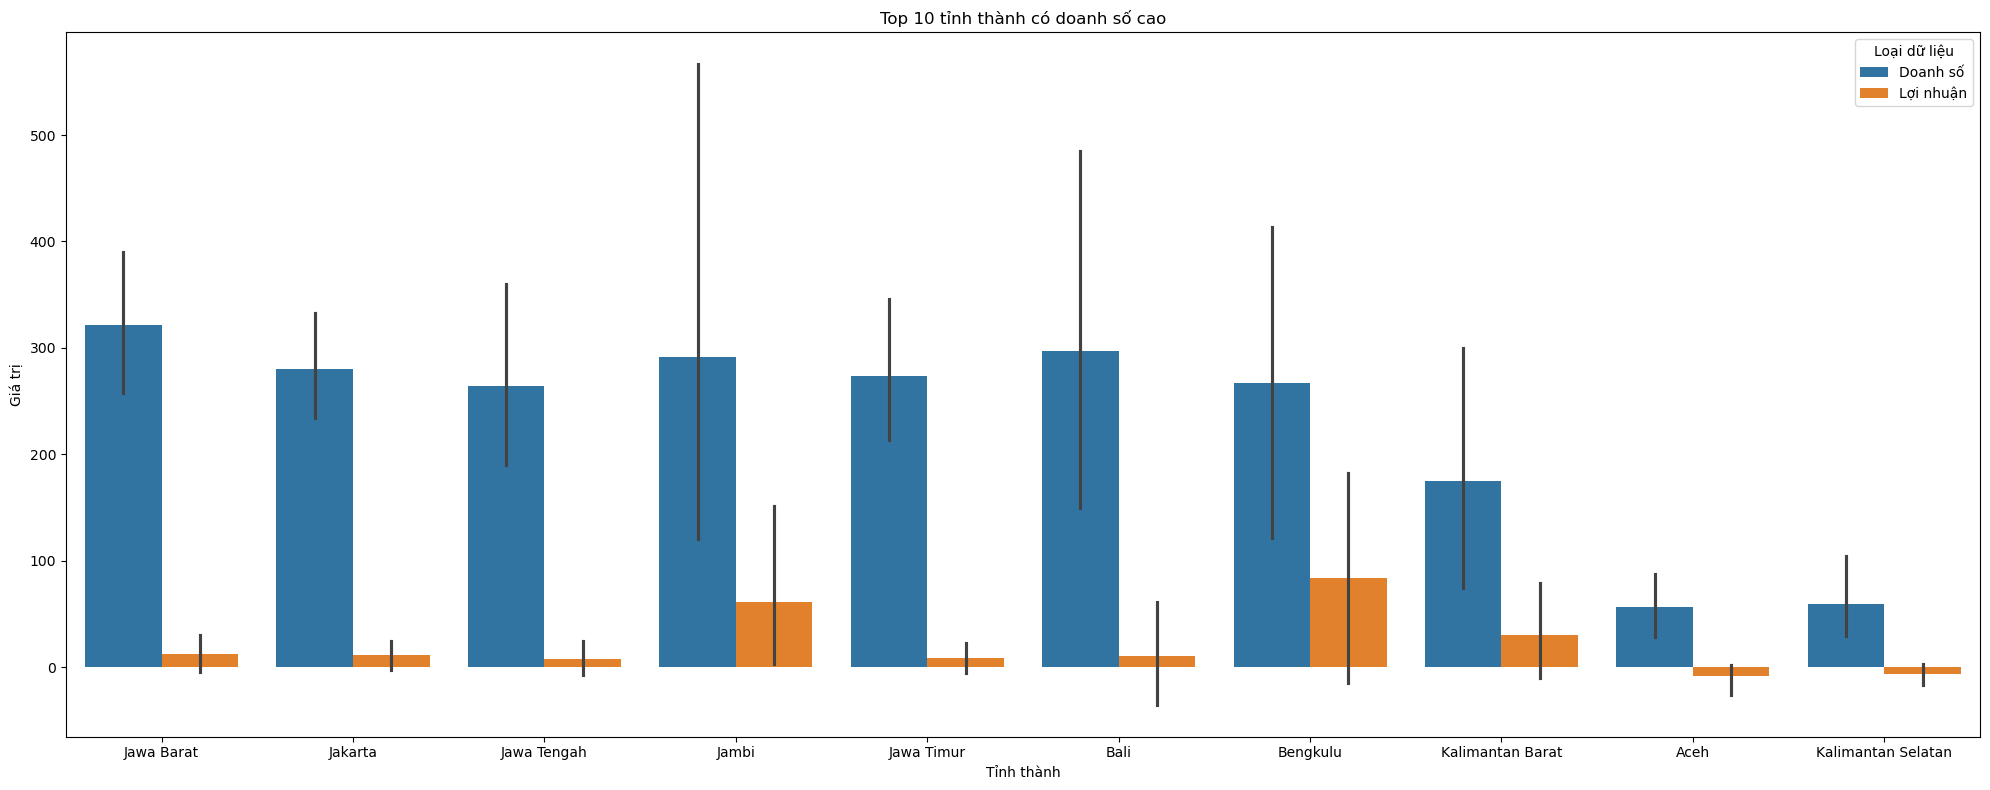

In [24]:
# Trực quan hóa 10 State có doanh số cao nhất
plot_df = indo_df[['State', 'Sales', 'Profit']] # Lọc ra State, doanh số và lợi nhuận
out_top_10 = plot_df.groupby('State')['Sales'].mean()[10:].reset_index()['State'].tolist() # lọc Top 10 State
plot_df = plot_df[~plot_df['State'].isin(out_top_10)] # chọn top 10
plot_df = plot_df.melt(id_vars = ['State'], var_name = 'Metric', value_name = 'Value') # chỉnh data

# Triển khai plot
plt.figure(figsize = (20, 8))
# Vẽ các cột doanh thu và lợi nhuận
sns.barplot(data = plot_df, x = 'State', y = 'Value', hue = 'Metric')
# Trang trí plot
plt.title('Top 10 tỉnh thành có doanh số cao')
plt.xlabel('Tỉnh thành')
plt.ylabel('Giá trị')
legend_labels = ['Doanh số', 'Lợi nhuận'] # gán nhãn doanh số và lợi nhuận
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, legend_labels, title='Loại dữ liệu')
plt.tight_layout()
# Show plot
plt.show()

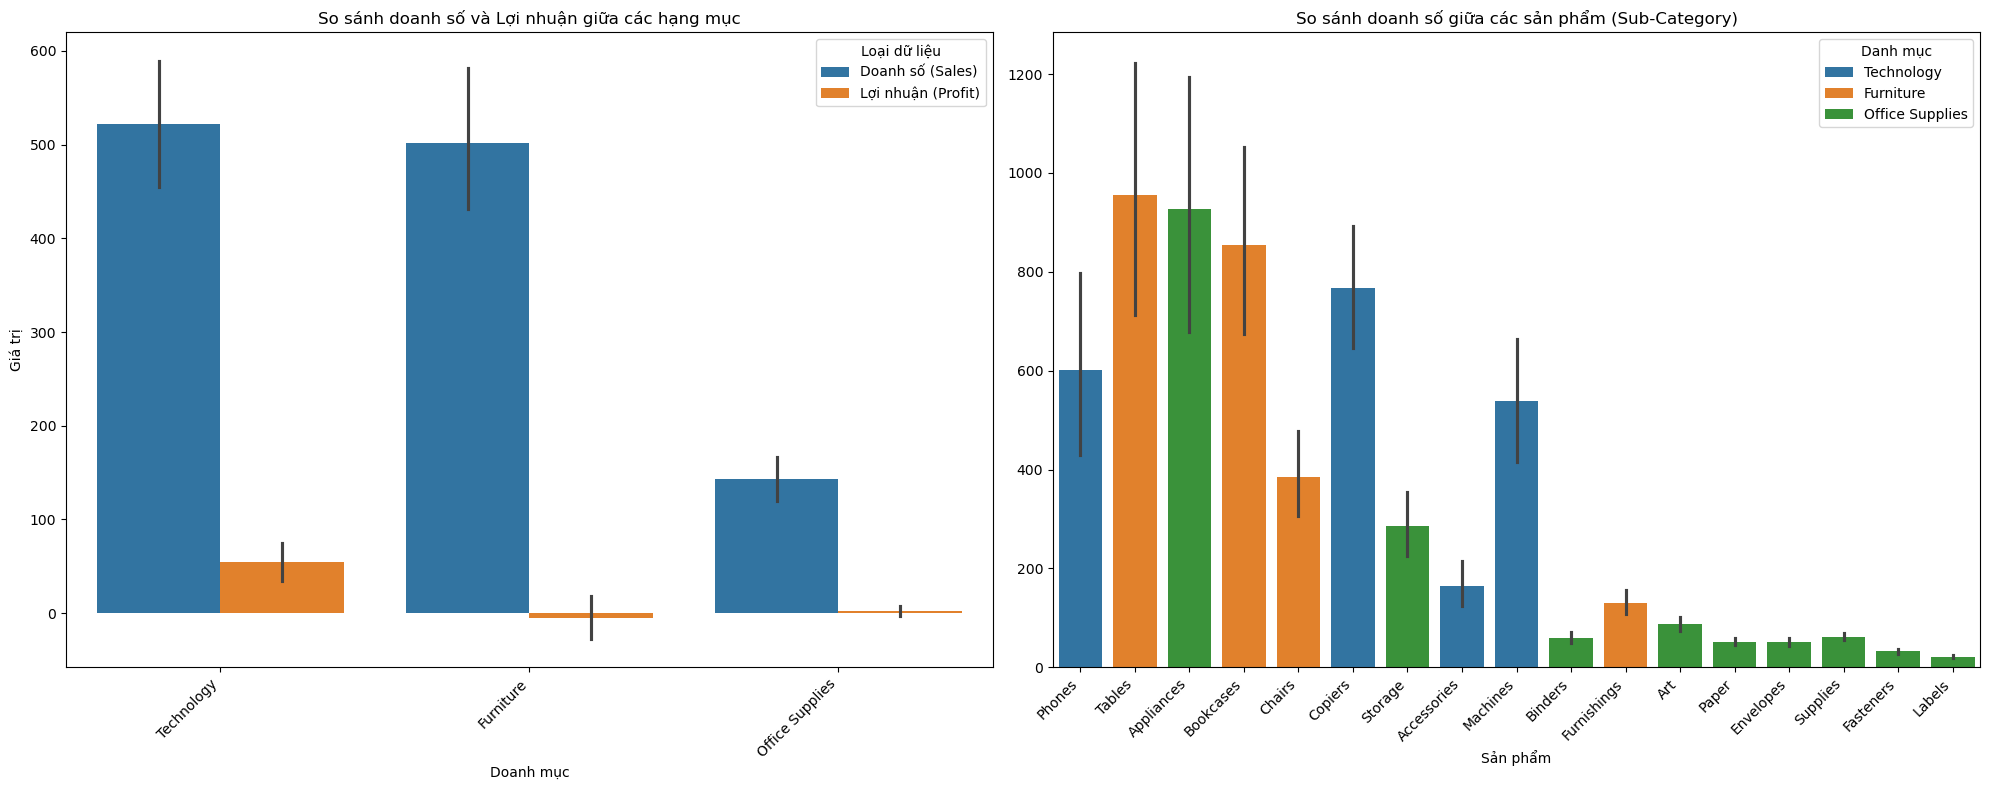

In [25]:
# Trực quan hóa doanh số và lợi nhuận theo category
category_df = indo_df[['Category', 'Sales', 'Profit']] # lọc các cột quan trọng
category_df = category_df.melt(id_vars = ['Category'], var_name = 'Metric', value_name = 'Value') # điều chỉnh data

sub_category_df = indo_df[['Sub-Category', 'Category', 'Sales', 'Profit']] # lọc ra cột sản phẩm

# Triển khai plot
fig, axes = plt.subplots(1, 2, figsize = (20, 8))
# Vẽ và trang trí plot
sns.barplot(data = category_df, x = 'Category', y = 'Value', hue = 'Metric',  ax = axes[0])
axes[0].set_title('So sánh doanh số và Lợi nhuận giữa các hạng mục')
axes[0].set_xlabel('Doanh mục')
axes[0].set_ylabel('Giá trị')
legend_labels = ['Doanh số (Sales)', 'Lợi nhuận (Profit)']
handles, _ = axes[0].get_legend_handles_labels()
axes[0].legend(handles, legend_labels, title="Loại dữ liệu")
# Vẽ và trang trí plot
sns.barplot(data = sub_category_df, x = 'Sub-Category', y = 'Sales', hue = 'Category', ax = axes[1])
axes[1].set_title('So sánh doanh số giữa các sản phẩm (Sub-Category)')
axes[1].set_xlabel('Sản phẩm')
axes[1].set_ylabel('')
axes[1].legend(title = 'Danh mục')
# quay trục x góc 45 độ
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
# Show plot
plt.show()

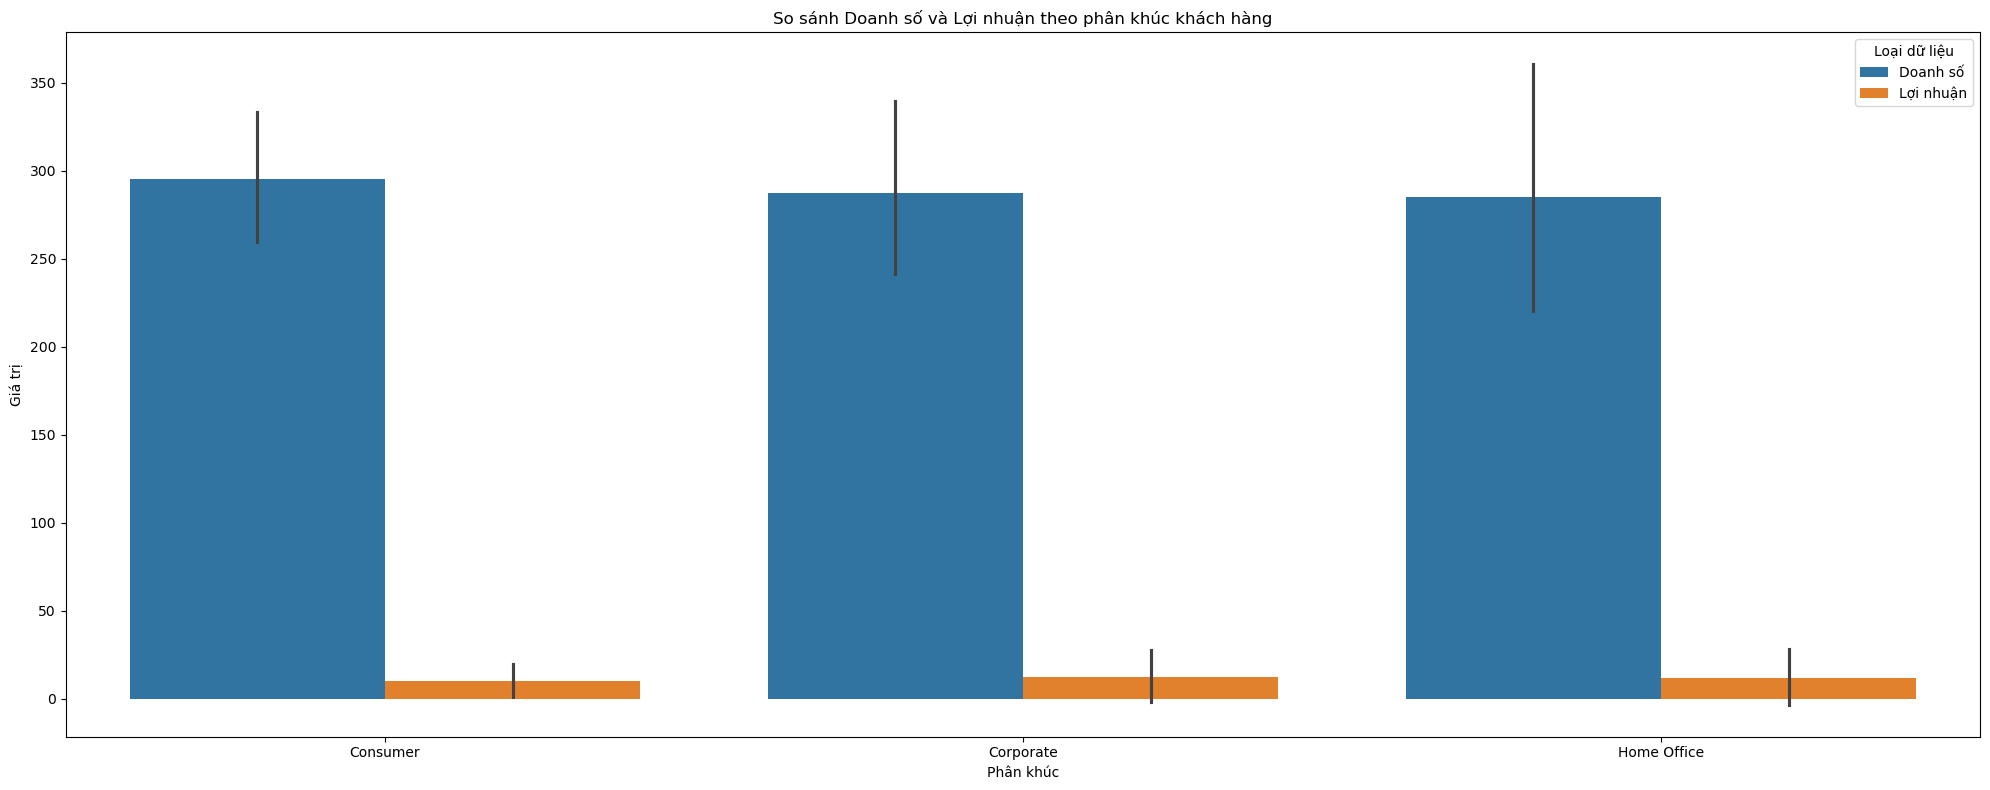

In [27]:
# Trực quan háo doanh số và lợi nhuận theo segment
segment_df = indo_df[['Segment', 'Sales', 'Profit']] # lọc các cột quan trọng
segment_df = segment_df.melt(id_vars = ['Segment'], var_name = 'Metric', value_name = 'Value') # điều chỉnh data

# Triển khai plot
plt.figure(figsize = (20, 8))
# Vẽ và trang trí plot
sns.barplot(data = segment_df, x = 'Segment', y = 'Value', hue = 'Metric')
# Trang trí plot
plt.title('So sánh Doanh số và Lợi nhuận theo phân khúc khách hàng')
plt.xlabel('Phân khúc')
plt.ylabel('Giá trị')
legend_labels = ['Doanh số', 'Lợi nhuận'] # gán nhãn lợi nhuận và doanh thu
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, legend_labels, title='Loại dữ liệu')
plt.tight_layout()
# Show plot
plt.show()

# Câu 4

In [ ]:
# Tổng quan về lợi nhuận theo danh mục sản phẩm
profit_by_category = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
profit_by_category

Category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: Profit, dtype: float64

In [ ]:
# Tổng quan về lợi nhuận theo phương thức vận chuyển
profit_by_ship_mode = df.groupby("Ship Mode")["Profit"].sum().sort_values(ascending=False)
profit_by_ship_mode

Ship Mode
Standard Class    890596.02120
Second Class      292583.52708
First Class       208104.67520
Same Day           76173.06780
Name: Profit, dtype: float64

In [ ]:
# Tổng quan về lợi nhuận theo phân khúc khách hàng
profit_by_segment = df.groupby("Segment")["Profit"].sum().sort_values(ascending=False)
profit_by_segment

Segment
Consumer       749239.78206
Corporate      441208.32866
Home Office    277009.18056
Name: Profit, dtype: float64

In [ ]:
# Tổng quan về lợi nhuận theo mức độ ưu tiên đơn hàng
profit_by_priority = df.groupby("Order Priority")["Profit"].sum().sort_values(ascending=False)
profit_by_priority

Order Priority
Medium      864203.76262
High        420373.51340
Critical    124224.16428
Low          58655.85098
Name: Profit, dtype: float64

Phân tích dữ liệu & Insight chính:

1. Danh mục sản phẩm (Category)
- Technology có lợi nhuận cao nhất (15.291,37) → Đây là ngành nên tập trung phát triển.
- Office Supplies có lợi nhuận thấp hơn (1.694,47).
- Furniture bị lỗ (-1.377,12) → Cần xem xét lại chiến lược kinh doanh cho nhóm này.

2. Phương thức vận chuyển (Ship Mode)
- Standard Class có lợi nhuận cao nhất (11.302,44) → Nên ưu tiên sử dụng phương thức này.
- Second Class và Same Day có lợi nhuận ổn định.
- First Class bị lỗ (-366,38) → Có thể do chi phí vận chuyển cao, cần đánh giá lại hiệu quả.

3. Phân khúc khách hàng (Segment)
- Consumer mang lại lợi nhuận cao nhất (7.445,64).
- Corporate cũng có lợi nhuận khá tốt (5.472,35).
- Home Office có lợi nhuận thấp nhất (2.690,73) → Cần tìm cách tiếp cận nhóm này hiệu quả hơn.

4. Mức độ ưu tiên đơn hàng (Order Priority)
- Medium và High có lợi nhuận cao nhất.
- Critical có lợi nhuận thấp (924,99).
- Low bị lỗ (-1.436,33) → Có thể do giảm giá nhiều hoặc biên lợi nhuận thấp.

Đề xuất giải pháp kinh doanh:

1. Tối ưu danh mục sản phẩm
- Tăng cường danh mục Technology vì đây là ngành có lợi nhuận cao nhất.
- Rà soát lại chiến lược giá và chi phí của Furniture, có thể tập trung vào dòng sản phẩm nội thất nhỏ gọn thay vì nội thất lớn để giảm chi phí vận chuyển và tồn kho.

2. Cải thiện chiến lược vận chuyển
- Khuyến khích khách hàng chọn Standard Class vì đây là phương thức vận chuyển có lợi nhuận tốt nhất.
- Cân nhắc cắt giảm hoặc định giá lại phí vận chuyển với First Class để tránh lỗ, có thể chỉ áp dụng với đơn hàng có giá trị cao hoặc khách VIP.

3. Tăng cường tiếp cận khách hàng doanh nghiệp
- Đẩy mạnh chiến lược tiếp thị cho nhóm Corporate, vì đây là nhóm khách hàng có tiềm năng lợi nhuận cao.
- Cải thiện chiến lược bán hàng cho nhóm Home Office bằng cách cung cấp ưu đãi phù hợp, như chương trình giảm giá theo số lượng hoặc gói combo sản phẩm.

4. Điều chỉnh chính sách ưu tiên đơn hàng
- Hạn chế giảm giá quá mức cho các đơn hàng Low Priority, vì nhóm này đang bị lỗ.
- Xây dựng chương trình khách hàng thân thiết dành cho nhóm khách hàng thường xuyên đặt hàng Medium và High Priority, khuyến khích họ mua nhiều hơn để tối ưu lợi nhuận.